# Titanic


#### The sinking of the RMS Titanic is one of the most infamous shipwrecks in history.  On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew. This sensational tragedy shocked the international community and led to better safety regulations for ships.

## Our challenge 

We have to analyse what sorts of people were likely to survive. In particular, we have to apply the tools of machine learning to predict which passengers survived the tragedy.

# Importing Libraries

In [1]:
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import Imputer
import seaborn as sns

In [2]:
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)


# Loading our dataset

In [3]:
train_data=pd.read_csv('../input/titanic/train.csv')
train_data.set_index('PassengerId',inplace=True)
test_data=pd.read_csv('../input/titanic/test.csv')
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Cleaning the dataset

In [4]:
#checking if there is missing value in training and testing dataset
print('Missing values in training dataset:\n')
print(train_data.isnull().sum())
print('\nMissing values in testing dataset:\n') 
print(test_data.isnull().sum())      

Missing values in training dataset:

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Missing values in testing dataset:

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## Treating missing values

In [5]:
# for training data
imp=Imputer(missing_values='NaN',strategy='median',axis=1)
Age_train=imp.fit_transform(train_data.Age.values.reshape(1,-1))
Age_train=Age_train.astype('int64').T
train_data['Age']=Age_train
train_data['Embarked'].fillna('S',inplace=True)
train_data.drop('Cabin',axis=1,inplace=True)
train_data.isnull().sum()


/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:66: DeprecationWarning: Class Imputer is deprecated; Imputer was deprecated in version 0.20 and will be removed in 0.22. Import impute.SimpleImputer from sklearn instead.
  warnings.warn(msg, category=DeprecationWarning)


Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [6]:
# for testing data
Age_test=imp.fit_transform(test_data.Age.values.reshape(1,-1))
Age_test=Age_test.astype('int64').T
test_data['Age']=Age_test
test_data['Fare'].fillna(np.mean(test_data['Fare']),inplace=True)
test_data.drop('Cabin',axis=1,inplace=True)
test_data.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [7]:
# converting sex column to categorical data
for sex in train_data.Sex:
    if sex=='female':
         train_data.replace(sex,0,inplace=True)
    else:
         train_data.replace(sex,1,inplace=True)
for sex in test_data.Sex:
    if sex=='female':
         test_data.replace(sex,0,inplace=True)
    else:
         test_data.replace(sex,1,inplace=True)    

# Plotting Survived distributions

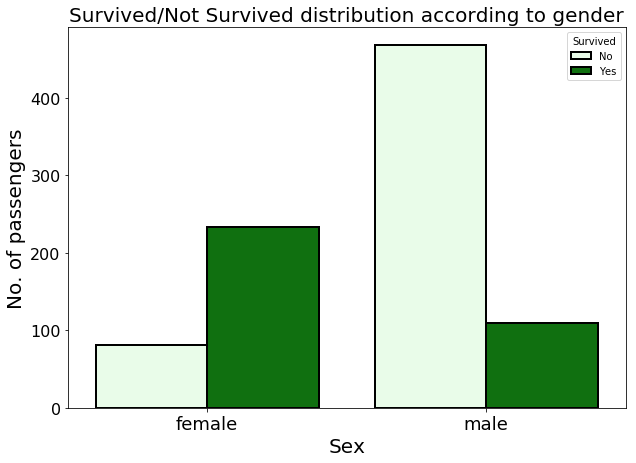

In [8]:
plt.figure(figsize=(10,7))
ax1=sns.countplot(x='Sex',hue='Survived',data=train_data,linewidth=2,edgecolor=(0,0,0),color='g')
plt.title("Survived/Not Survived distribution according to gender",fontsize=20)
labels=['female','male']
plt.xticks(sorted(train_data.Survived.unique()),labels,fontsize=18)
plt.yticks(fontsize=16)
plt.xlabel('Sex',fontsize=20)
plt.ylabel('No. of passengers',fontsize=20)
leg=ax1.get_legend()
leg.set_title('Survived')
leg.texts[0].set_text('No')
leg.texts[1].set_text('Yes')

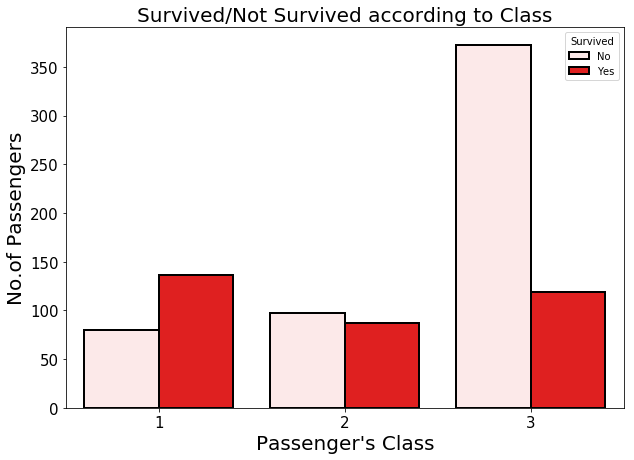

In [9]:
plt.figure(figsize=(10,7))
ax2=sns.countplot(x='Pclass',hue='Survived',data=train_data,edgecolor=(0,0,0),linewidth=2,color='r')
plt.title('Survived/Not Survived according to Class',fontsize=20)
plt.xlabel('Passenger\'s Class',fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel('No.of Passengers',fontsize=20)
plt.yticks(fontsize=15)
leg=ax2.get_legend()
leg.texts[0].set_text('No')
leg.texts[1].set_text('Yes')


### From above graph we can see that survial is directly depend on the Class.

1st class passenger survived percentage is ~63%

2nd class passenger survived percentage is ~47%

3rd class passenger survived percentage is only ~24%


# Feature Engineering

In [10]:
train_data.drop(['Name','Ticket'],axis=1,inplace=True)
test_data.drop(['Name','Ticket'],axis=1,inplace=True)
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,1,22,1,0,7.2500,S
2,1,1,0,38,1,0,71.2833,C
3,1,3,0,26,0,0,7.9250,S
4,1,1,0,35,1,0,53.1000,S
5,0,3,1,35,0,0,8.0500,S


In [11]:
# creating age group feature
def age_group(age):
    a=''
    if (age<=1):
        a='infant'
    elif (1<age<=10):
        a='child'
    elif (10<age<=17):
        a='teenager'
    elif (17<age<=30):
        a='young_adult'
    elif (30<age<=40):
        a='adult'    
    else:
        a='old'
    return a
train_data['Age_group']=train_data.Age.map(age_group)
test_data['Age_group']=test_data.Age.map(age_group)

In [12]:
# creating family group feature
train_data['family_size']=train_data['SibSp']+train_data['Parch']+1
test_data['family_size']=test_data['SibSp']+test_data['Parch']+1
def family_group(family_size):
    a=''
    if family_size<=1:
        a='alone'
    elif family_size<4:
        a='small'
    else:
        a='large'
    return a
train_data['family_group']=train_data.family_size.map(family_group)
test_data['family_group']=test_data.family_size.map(family_group)


In [13]:
# creating fare_per_person column
train_data['fare_per_person']=train_data['Fare']/train_data['family_size']
test_data['fare_per_person']=test_data['Fare']/test_data['family_size']
# creating fare_group feature
def fare_group(fare):
    a=''
    if fare<10:
        a='very_low'
    elif fare<20:
        a='low'
    elif fare<30:
        a='medium'
    elif fare<40:
        a='high'
    else:
        a='very high'
    return a    
train_data['fare_group']=train_data.fare_per_person.map(fare_group)      
test_data['fare_group']=test_data.fare_per_person.map(fare_group)        

In [14]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_group,family_size,family_group,fare_per_person,fare_group
PassengerId,,,,,,,,,,,,,
1,0,3,1,22,1,0,7.2500,S,young_adult,2,small,3.62500,very_low
2,1,1,0,38,1,0,71.2833,C,adult,2,small,35.64165,high
3,1,3,0,26,0,0,7.9250,S,young_adult,1,alone,7.92500,very_low
4,1,1,0,35,1,0,53.1000,S,adult,2,small,26.55000,medium
5,0,3,1,35,0,0,8.0500,S,adult,1,alone,8.05000,very_low


In [15]:
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_group,family_size,family_group,fare_per_person,fare_group
0,892,3,1,34,0,0,7.8292,Q,adult,1,alone,7.829200,very_low
1,893,3,0,47,1,0,7.0000,S,old,2,small,3.500000,very_low
2,894,2,1,62,0,0,9.6875,Q,old,1,alone,9.687500,very_low
3,895,3,1,27,0,0,8.6625,S,young_adult,1,alone,8.662500,very_low
4,896,3,0,22,1,1,12.2875,S,young_adult,3,small,4.095833,very_low


## Creating dummy variables

In [16]:
# creating dummy variables for Embarked,age_group, family_group 
train_data=pd.get_dummies(train_data,columns=['Embarked','Age_group','family_group','fare_group'],drop_first=True)
train_data.head()
test_data=pd.get_dummies(test_data,columns=['Embarked','Age_group','family_group','fare_group'],drop_first=True)

In [17]:
# drop unnecessary columns
train_data.drop(['Age','SibSp','Parch','Fare','family_size','fare_per_person'],axis=1,inplace=True)
test_data.drop(['Age','SibSp','Parch','Fare','family_size','fare_per_person'],axis=1,inplace=True)

In [18]:
test_data.head()

,PassengerId,Pclass,Sex,Embarked_Q,Embarked_S,Age_group_child,Age_group_infant,Age_group_old,Age_group_teenager,Age_group_young_adult,family_group_large,family_group_small,fare_group_low,fare_group_medium,fare_group_very high,fare_group_very_low
0,892,3,1,1,0,0,0,0,0,0,0,0,0,0,0,1
1,893,3,0,0,1,0,0,1,0,0,0,1,0,0,0,1
2,894,2,1,1,0,0,0,1,0,0,0,0,0,0,0,1
3,895,3,1,0,1,0,0,0,0,1,0,0,0,0,0,1
4,896,3,0,0,1,0,0,0,0,1,0,1,0,0,0,1


In [19]:
train_data.head()

,Survived,Pclass,Sex,Embarked_Q,Embarked_S,Age_group_child,Age_group_infant,Age_group_old,Age_group_teenager,Age_group_young_adult,family_group_large,family_group_small,fare_group_low,fare_group_medium,fare_group_very high,fare_group_very_low
PassengerId,,,,,,,,,,,,,,,,
1,0,3,1,0,1,0,0,0,0,1,0,1,0,0,0,1
2,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,1,3,0,0,1,0,0,0,0,1,0,0,0,0,0,1
4,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0
5,0,3,1,0,1,0,0,0,0,0,0,0,0,0,0,1


### Creating Features and Labels

In [20]:
X_train=train_data.drop('Survived',1)
y_train=train_data['Survived']
X_test=test_data.drop('PassengerId',1)
X_train.shape

(891, 15)

# Calculating cross_val_score

### We are calculating cross_val_score for following classifiying models

KNeighborsClassifier

GaussianNB

LogisticRegression

DecisionTreeClassifier

RandomForestClassifier

SVC



## KNeighborsClassifier

In [21]:
clf=KNeighborsClassifier(n_neighbors=3)
scoring='accuracy'
score_1=cross_val_score(clf,X_train,y_train,n_jobs=1,cv=5,scoring=scoring)
score_1=round(np.mean(score_1)*100,2)
score_1

79.13

## GaussianNB

In [22]:
clf=GaussianNB()
scoring='accuracy'
score_2=cross_val_score(clf,X_train,y_train,n_jobs=1,cv=5,scoring=scoring)
score_2=round(np.mean(score_2)*100,2)
score_2

74.2

## LogisticRegression

In [23]:
clf=LogisticRegression()
scoring='accuracy'
score_3=cross_val_score(clf,X_train,y_train,n_jobs=1,cv=5,scoring=scoring)
score_3=round(np.mean(score_3)*100,2)
score_3

79.58

## DecisionTreeClassifier

In [24]:
clf=DecisionTreeClassifier(max_depth=5)
scoring='accuracy'
score_4=cross_val_score(clf,X_train,y_train,n_jobs=1,cv=5,scoring=scoring)
score_4=round(np.mean(score_4)*100,2)
score_4

80.13

## RandomForestClassifier

In [25]:
clf=RandomForestClassifier(n_estimators=20)
scoring='accuracy'
score_5=cross_val_score(clf,X_train,y_train,n_jobs=1,cv=5,scoring=scoring)
score_5=round(np.mean(score_5)*100,2)
score_5

81.04

## SVC

In [26]:
clf=SVC(probability=True)
scoring='accuracy'
score_6=cross_val_score(clf,X_train,y_train,n_jobs=1,cv=5,scoring=scoring)
score_6=round(np.mean(score_6)*100,2)
score_6

78.67

# Comparing cross_val_score

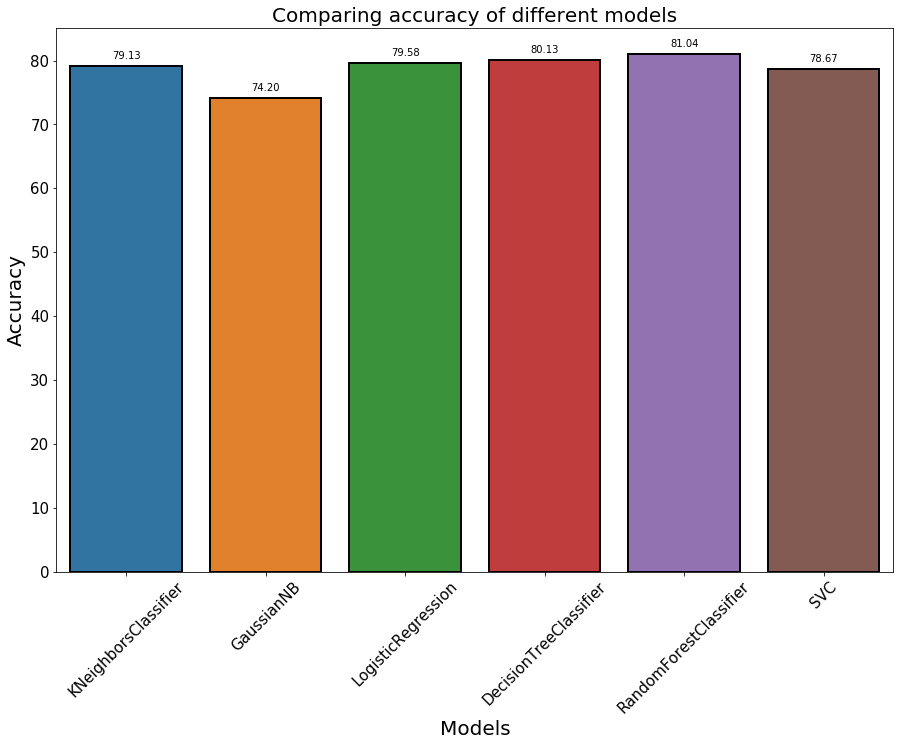

In [27]:
plt.figure(figsize=(15,10))
y=[score_1,score_2,score_3,score_4,score_5,score_6]
x=['KNeighborsClassifier',
   'GaussianNB',
   'LogisticRegression',
   'DecisionTreeClassifier',
   'RandomForestClassifier',
   'SVC']
plt.title('Comparing accuracy of different models',fontsize=20)
splot=sns.barplot(x,y,edgecolor=(0,0,0),linewidth=2)
plt.xticks(fontsize=15,rotation=45)
plt.yticks(fontsize=15)
plt.xlabel('Models',fontsize=20)
plt.ylabel('Accuracy',fontsize=20)
for p in splot.patches:
    splot.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')



# Creating Model

In [28]:
clf=RandomForestClassifier(n_estimators=20)
# training our model
clf.fit(X_train,y_train)
#predicting for test dataset
prediction=clf.predict(X_test)

In [29]:
# creating our submission dataframe
submission=pd.DataFrame({'PassengerId':sorted(test_data['PassengerId']),'Survived':prediction})
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [30]:
# writing to csv file
submission.to_csv('submission.csv',index=False)